# Øving 03 numerikk

## Spørsmål 01

Vi ser på startverdiproblemet

$x′=\frac{1}{x}, \space \space \space \space \space \space x(0)=5$

Utfør to steg med Eulers metode og skrittlengde $h=\frac{4}{5}$. Det vil si, gitt $x_0=x(0)$, finn $x_2$.

Her godtar vi et slingringsmonn på 0.005 (absolutt feil) fra det eksakte svaret.

$x_2 = 5.3144$

In [ ]:
# Eulers metode med h=45, x0=5, f(x) = 1/x
h = 4/5
x0 = 5

# Definer funksjonen f(x)
def f(x):
    return 1 / x

# Steg 1: Beregn x1
x1 = x0 + h * f(x0)

# Steg 2: Beregn x2
x2 = x1 + h * f(x1)

x2


## Spørsmål 2

Vi ser på differensialligningen $x′=−9𝑥(1)$ hvor absoluttverdien av den eksakte løsningen $x(t)=x(0)e^{−9t}$ avtar med økende verdier av $t$. Hvor liten må skrittlengden $h$ velges for at Eulers metode skal gi tilnærminger $x_n$ til løsningen av $(1)$ hvor $|x_n|$ avtar med økende $n$?

$h < \frac{2}{9}$ (Oppgi svaret som brøk)

For skrittlengder $h$ som oppfyller kriteriet ovenfor, hva er det minste antallet steg $N$ vi må utføre for å kunne tilnærme $x(5)$ med Eulers metode?

$N = 23$

In [3]:
from sympy import symbols, solve

# Definer variabelen h
h = symbols('h')

# Betingelse for stabilitet i Eulers metode: 1 - 9h > -1
inequality = 1 - 9*h > -1

# Løs for h
h_solution = solve(inequality, h)
print(f"H < {h_solution}")


H < (-oo < h) & (h < 2/9)


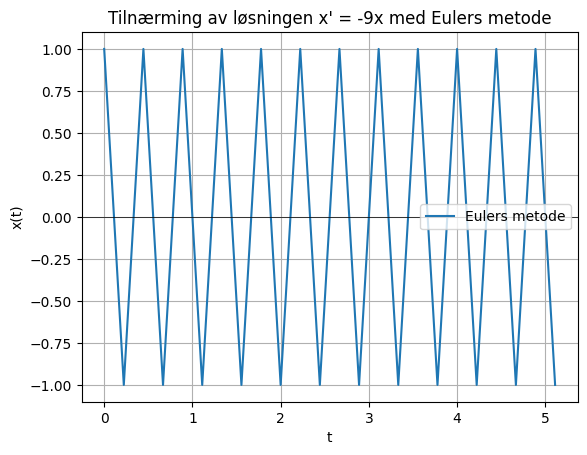

N = 23


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Eulers metode for differensialligning x' = -9x
def euler_method(x0, h, t_end):
    t_values = np.arange(0, t_end + h, h)  # tidsverdier
    x_values = np.zeros_like(t_values)     # x verdier for løsning
    x_values[0] = x0                       # initialverdi

    for i in range(1, len(t_values)):
        x_values[i] = x_values[i-1] + h * (-9 * x_values[i-1])

    return t_values, x_values

# Parametere
x0 = 1    # initialverdi x(0) = 1
h = 2/9   # skrittlengde
t_end = 5 # tid vi ønsker å tilnærme

# Utfør Eulers metode
t_values, x_values = euler_method(x0, h, t_end)

# Plot resultatet
plt.plot(t_values, x_values, label="Eulers metode")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Tilnærming av løsningen x\' = -9x med Eulers metode')
plt.axhline(0, color='black',linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()

# Antall steg N for tilnærming av x(5)
N = len(t_values) - 1
print(f"N = {N}")

## Spørsmål 3

I denne oppgaven er vi gitt retningsfelt for fire ulike differensialligninger
𝑥′=𝑓(𝑡,𝑥),

nemlig

1. $f(t, x) = cos(\pi x)$
2. $f(t, x) = \frac{1}{1 + x^2}$
3. $f(t, x) = t - x$
4. $f(t, x) = t^2 - x^2$

For hver av differensialligningene bruker vi Eulers metode for å tilnærme verdien av $x(2)$
for startverdiproblemet med $x(0)=0$: først med skrittlengde $h=1$, deretter med $h=0.5$. Legg merke til hvordan man i Eulers metode finner $x_{k+1}$ ved å starte i punktet $(t_,x_k)$ og gå parallelt med retningsfeltet $(1,f(t_k,x_k))$ til man når $(t_{k+1},x_{k+1}$).

Her skal du koble riktig bilde med riktig differensialligning.

Se bilder

## Spørsmål 4

Vi er gitt integralligningen
$x(t) = 4 + \int^t _0 \ sin(sx(s))ds$

som er vanskelig å løse eksakt. Vi vil i stedet bruke Eulers metode til å tilnærme løsningen, men da behøver vi et startverdiproblem. Hva er startverdiproblemet som tilsvarer denne integralligningen?

$x′= $ - Ikke $sin(t * x(t))$?

$x(0)= 4/1$

Hint 1: Gitt en kontinuerlig funksjon $f = f(x)$ kan vi definere $F$ som

$F(x) = \int ^x _a \ f(y)dy$

for en konstant 𝑎. Da har vi at $F'(x) = f(x)$

Hint 2: For en kontinuerlig funksjon $f$ og en konstant $a$ har vi at
$\int ^a _a \ f(x)dx = 0$


Bruk Eulers metode med skrittlengde $h=\frac{1}{2}$
for å tilnærme $x(1)$ for integralligningen.

$x(1) \approx 4.455$

In [4]:
import numpy as np

# Definer Eulers metode for integralligningen med utskrifter
def euler_method_step_by_step(f, x0, h, t_end):
    t_values = np.arange(0, t_end + h, h)  # tidsverdier
    x_values = np.zeros_like(t_values)     # x-verdier for løsning
    x_values[0] = x0                       # initialverdi

    print(f"x'(t) = sin(t * x(t))")        # Skriv ut differensialligning

    # Iterer over tidsverdier
    for i in range(1, len(t_values)):
        print(f"x({t_values[i-1]}) = {x_values[i-1]}")  # Skriv ut forrige verdi
        x_values[i] = x_values[i-1] + h * f(t_values[i-1], x_values[i-1])  # Beregn ny verdi
        print(f"x({t_values[i]}) = {x_values[i]}")      # Skriv ut ny verdi
        print("-" * 30)                                 # Skillelinje mellom trinn

    return x_values[-1]

# Definer funksjonen f(t, x) = sin(t * x)
def f(t, x):
    return np.sin(t * x)

# Parametere
x0 = 4        # initialverdi x(0) = 4
h = 0.5       # skrittlengde
t_end = 1     # tid vi ønsker å tilnærme

# Utfør Eulers metode med skrittlengde h
x_at_1 = euler_method_step_by_step(f, x0, h, t_end)

print(f"x(1) ≈ {x_at_1}")


x'(t) = sin(t * x(t))
x(0.0) = 4.0
x(0.5) = 4.0
------------------------------
x(0.5) = 4.0
x(1.0) = 4.4546487134128405
------------------------------
x(1) ≈ 4.4546487134128405


## Spørsmål 5

Her ser vi på startverdiproblemet

$x' = t - x$ , $x(0) = 0$

Vi ønsker å tilnærme den eksakte løsningen $x(t)$
for $t=2$ med Eulers metode, og partisjonerer derfor intervallet $[0,2]$ med $t_n = nh$, $h=\frac{2}{N}$ for $n = 0,…,N$.

Det er oppgitt at den eksakte løsningen har verdien $x(2)=1+e^{−2}$. Hva er det minste antallet steg med Eulers metode som gir et avvik $|x(2)−x_N|$ som er mindre enn $10^{−2}$?

Bruk feltet nedenfor til å implementere Eulers metode for ligning (1), og prøv deg fram til du får en tilnærming som oppfyller kravet ovenfor. Her er det viktig at du lagrer antall steg $N$
som variabelen `N` og siste iterat $x_N$ som variabelen `x`.

Hint: Her kan det nok være lettere å prøve seg fram i f.eks. Jupyter Notebook, før du legger inn den fungerende løsningen her.

For eksempel:

| Test                                                                                                  | 	Result                                                |
|-------------------------------------------------------------------------------------------------------|--------------------------------------------------------|
| `err = np.abs(1+np.exp(-2)-x)` <br/> `print('Avviket (med seks gjeldende siffer) er {:.6f}'.format(err))` | `Avviket (med seks gjeldende siffer) er 0.009782`      |


In [5]:
# Retard CapQuiz code checker.

import numpy as np

# Definer funksjonen for differensialligningen x' = t - x
def f(t, x):
    return t - x

# Eulers metode for differensialligning
def euler_method(f, x0, h, t_end):
    N = int(t_end / h)  # Antall steg
    t_values = np.linspace(0, t_end, N+1)  # tidsverdier
    x_values = np.zeros(N+1)  # x-verdier for løsning
    x_values[0] = x0  # initialverdi

    # Iterer gjennom tidsstegene
    for i in range(1, N+1):
        x_values[i] = x_values[i-1] + h * f(t_values[i-1], x_values[i-1])

    return x_values[-1], N

# Startverdier
x0 = 0  # x(0) = 0
t_end = 2  # t = 2

# Eksakt verdi av x(2) = 1 + exp(-2)
exact_value = 1 + np.exp(-2)

# Iterer over forskjellige skrittlengder (h) for å finne minimum N
tolerance = 1e-2  # Kravet for avvik
N = 1
err = float('inf')

while err > tolerance:
    h = 2 / N
    x_N, N = euler_method(f, x0, h, t_end)
    err = np.abs(exact_value - x_N)
    N += 1

# Tilnærmet verdi x
x = x_N

# Beregn avviket
err = np.abs(1 + np.exp(-2) - x)
print('Avviket (med seks gjeldende siffer) er {:.6f}'.format(err))

(0.009781771168009268, 28, 1.1255535120686035)

## Spørsmål 6

Vi ser på den lineære differensialligningen
$x'(t) = t - x(1)$

og vil tilnærme løsninger av det tilhørende startverdiproblemet med Eulers metode. Gitt startpunktet $t_0$ og en skrittlengde $h > 0$ definerer vi $t_n = nh$ for heltall $n$. Tilnærmingen $x_n$ av løsningen $x(t)$ i punktet $t = t_n$ er da gitt av

$x_{n+1} = x_n + hf(t_n, x_n)$,

som tilsvarer at vi tilnærmer den deriverte med en foroverdifferanse.

For at Eulers metode skal være stabil må skrittlengden $h$ velges liten nok. Dette er ikke et problem om vi isteden bruker såkalte implisitt Eulers metode,

$x_{n+1} = x_n + hf(t_{n+1}, x_{n+1}$

som tilsvarer å tilnærme den deriverte med en bakoverdifferanse. Avhengig av formen på $f(t, x) kan det her være mer vrient å finne neste verdi $x_{n+1} siden vi må løse en ligning.
Differensialligningen (1) ovenfor er heldigvis lineær i den ukjente $x$, og dermed er det ikke vanskelig å løse for $x_{n+1}$.

Nedenfor er vi gitt en fungerende kode for eksplisitt Eulers metode for denne ligningen.
Din oppgave er å endre på koden slik at den i stedet gir oss tilnærmingen gitt av implisitt Eulers metode.


```
# Startkode. Må brukes for riktig svar.

import numpy as np

def implisittEuler(x_start,t_start,t_slutt,steg):
# beregner tilnærmet løsning i 't_slutt' med 'steg' antall steg og startverdi 'x_start' ved 't_start'
# for differensialligningen x' = -x+t
    x = x_start
    tk, h = np.linspace(t_start,t_slutt,steg+1,retstep=True) # beregner t_k og h
    
    for k in range(steg):
        x = x + h*(tk[k] - x)
    return x
```

In [6]:
import numpy as np

# Implisitt Euler metode implementasjon for x'(t) = t - x(1)
def implisittEuler(x_start, t_start, t_slutt, steg):
    # Beregner tilnærmet løsning i 't_slutt' med 'steg' antall steg og startverdi 'x_start' ved 't_start'
    # for differensialligningen x' = t - x
    x = x_start
    tk, h = np.linspace(t_start, t_slutt, steg+1, retstep=True)  # Beregn t_k og h

    for k in range(steg):
        # Implisitt Eulers metode: x_{n+1} = (x_n + h * t_{n+1}) / (1 + h)
        x = (x + h * tk[k+1]) / (1 + h)

    return x

# Parametere for testen
x0 = 0
t0 = 0
t1 = 2
steg = 11

# Utfør testen
x1 = implisittEuler(x0, t0, t1, steg)

Tilnærmet løsning ved t = 2: 1.1615055828898462


## Oppgave 7

Vi ser på den inhomogene (det vil si at høyresiden ikke er null), andreordens differensialligningen

(1): $x''(t) + x'(t) - 2x(t) = sin(t)$

I et kurs om differensialligninger kunne man lært å løse denne typen ligninger analytisk, men her vil vi heller løse den numerisk med Eulers metode. For å gjøre dette må vi først skrive den om til et førsteordens system av differensialligninger (koblede differensialligninger). For å få til dette innfører vi den nye variabelen $y$
som skal oppfylle $y = x'$. Da skal ligning (1) kunne skrives om som
$$
\begin{bmatrix}
x'(t)) \\
y'(t)
\end{bmatrix}
= A
\begin{bmatrix}
x(t)) \\
y(t)
\end{bmatrix}
\ + f(t)
$$

Hva er matrisen $A$ og vektoren $f(t)$ her?

$$
A =
\begin{bmatrix}
0 & 1 \\
2 & -1
\end{bmatrix}
$$

$$
f(t) =
\begin{bmatrix}
0 \\
sin(t)
\end{bmatrix}
$$

In [7]:
# Ingen kode til spørsmål 7

## Spørsmål 8

La oss nå se på startverdiproblemet

$x'' + x' - 2x = sin(t)$, $x(0) = 1$, $x'(0) = 0$

Vi vil bruke førsteordenssystemet fra forrige oppgave og Eulers metode med skrittlengde $h=0.1$ til å tilnærme løsningen $x(t)$ ved $t = 1$.

Bruk feltet nedenfor til å implementere denne tilnærmingen med Eulers metode.
Her er det viktig at du lagrer tilnærmingene av $x(1)$ og $x′(1)$ henholdsvis som variablene ´x´ og ´y´.


```
import numpy as np

# Skriv inn koden din er
```

In [9]:
import numpy as np

# Definer Eulers metode for førsteordenssystemet
def euler_method_system(x0, y0, t0, t_end, h):
    # Antall steg
    N = int((t_end - t0) / h)

    # Initialverdier
    t_values = np.linspace(t0, t_end, N+1)  # tidsverdier
    x_values = np.zeros(N+1)  # x(t) verdier
    y_values = np.zeros(N+1)  # y(t) verdier

    x_values[0] = x0  # x(0) = 1
    y_values[0] = y0  # x'(0) = 0

    # Matrisen A
    A = np.array([[0, 1],
                  [2, -1]])

    # Eulers metode
    for k in range(N):
        x = x_values[k]
        y = y_values[k]

        # Beregn neste verdi for x og y
        dxdt = A[0, 0] * x + A[0, 1] * y
        dydt = A[1, 0] * x + A[1, 1] * y + np.sin(t_values[k])

        x_values[k+1] = x + h * dxdt
        y_values[k+1] = y + h * dydt

    return x_values[-1], y_values[-1]

# Startverdier
x0 = 1  # x(0) = 1
y0 = 0  # x'(0) = 0
t0 = 0  # Starttid
t_end = 1  # Sluttid
h = 0.1  # Skrittlengde

# Beregn tilnærmet løsning ved t = 1
x, y = euler_method_system(x0, y0, t0, t_end, h)

# Skriv ut resultatene
x
y

print(f"x(1) = {x}") # Må fjernes for å klare kodesjekken i Cap
print(f"x'(1) = {y}") # Må fjernes for å klare kodesjekken i Cap

x(1) = 1.8662452659189164
x'(1) = 2.0107178282214226
